# DS 2010 Student Success Prediction
### Nick Golprvar, Joseph D'Angelo, Nora Cleary, Ryan Zappone

In [2]:
# first, we need to import the file into pandas so we can process it.

import pandas as pd

dataframe = pd.read_csv("./student_performance_interactions.csv")
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   object 
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   object 
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13  physical_activity_minutes  1000 non-null   float6

In [3]:
# next, let's clean the data.

# student id isn't indicative of anything, so we don't need it.
dataframe = dataframe.drop(columns=['student_id'])

# we are trying to predict final score. The grade column is a redundancy (not linearly independent from the final score column).
dataframe = dataframe.drop(columns=['grade'])

# same with pass_fail.
dataframe = dataframe.drop(columns=['pass_fail'])

# we assign numerical values to categorical ordinal data, like study environment, and parent educational level. 
# We do this ordinal encoding so we can observe relationships between the columns using mathematics.

# study environment (lower is better).
study_environment_map = {
    'Quiet': 0,
    'Moderate': 1,
    'Noisy': 2
}
dataframe['study_environment'] = dataframe['study_environment'].map(study_environment_map)

# parent education level (higher is better).
parent_education_level_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2
}
dataframe['parent_education_level'] = dataframe['parent_education_level'].map(parent_education_level_map)

dataframe.head()

,final_score,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,60.137241,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,2,2
1,99.021977,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,0,0
2,70.522955,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,0,1
3,63.448537,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,0,2
4,66.483019,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,2,0


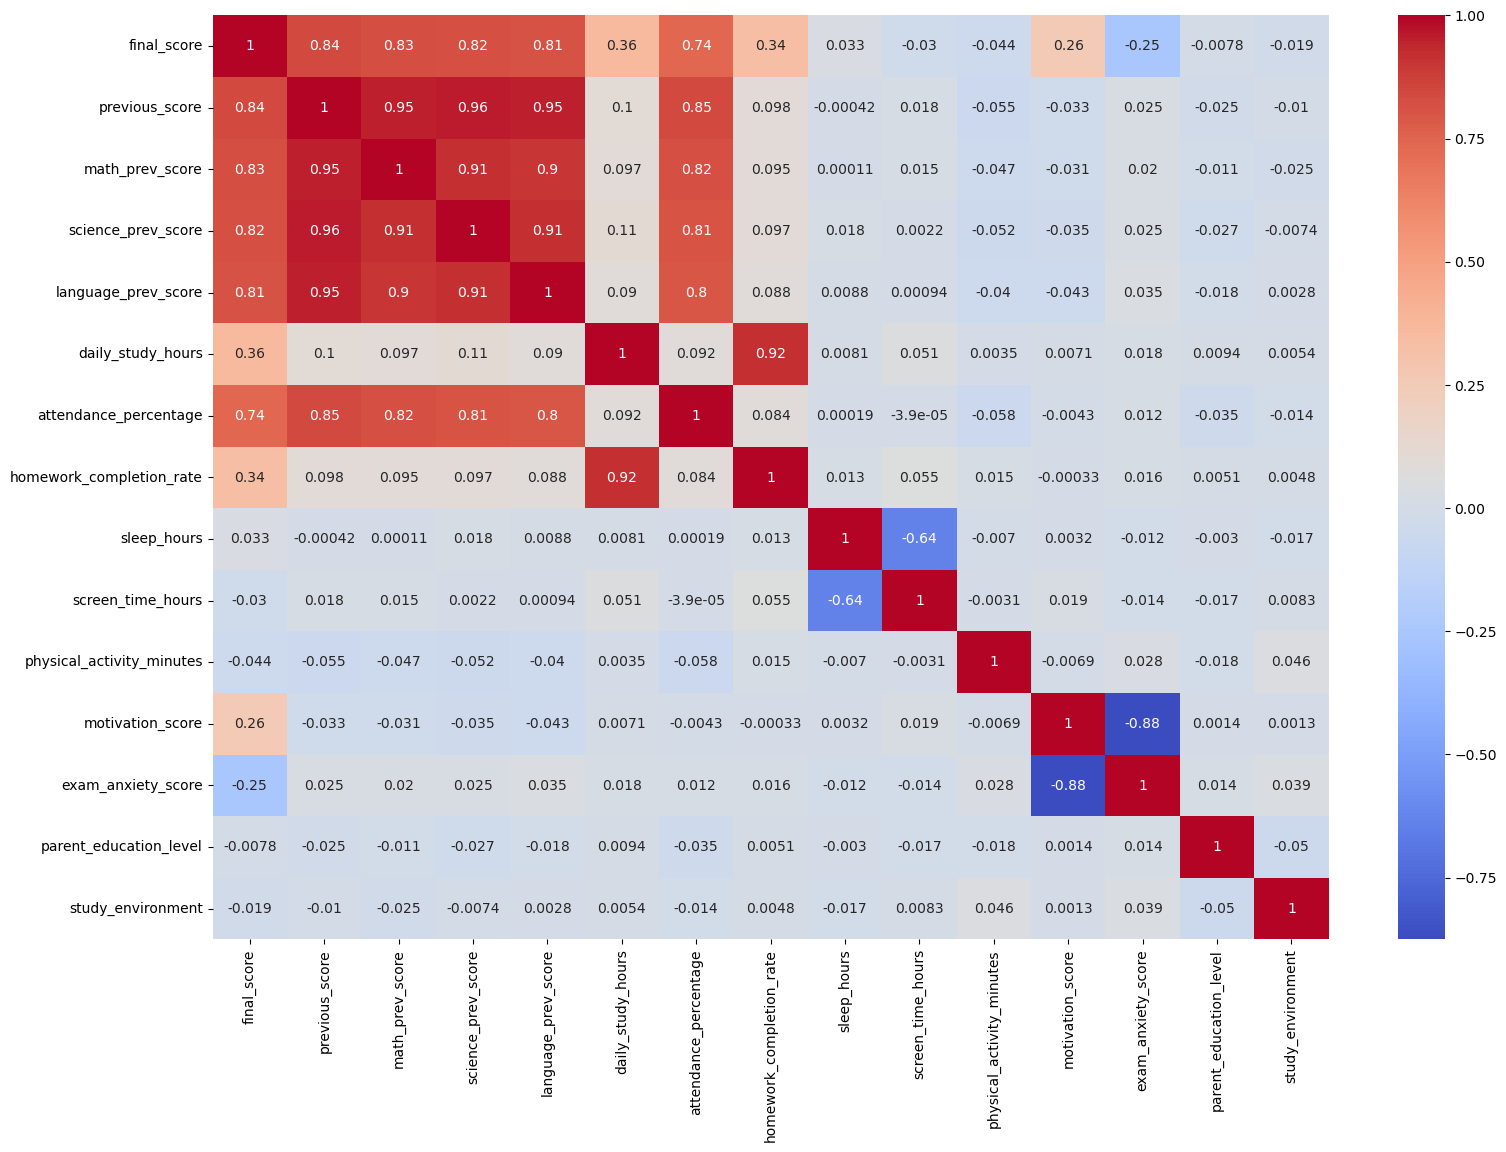

In [4]:
# wow that our data contains only numerical values, we can observe the correlation matrix
# this will allow us to see what columns are positvely correlated, or negatively correlated, to one another.

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = dataframe.corr(numeric_only=True)

plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [5]:
# let's create a regression model to try and predict student final scores.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# we want to try and predict the final score, so we drop it from our inputs, and treat it as the target.
x = dataframe.drop("final_score", axis=1)
y = dataframe["final_score"]

# split the data: 80% training & 20% testing.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# train the model.
model = LinearRegression()
model.fit(x_train, y_train)

# with our model trained, we can now evaluate it.
y_pred = model.predict(x_test)

# As we learned in lecture, a lower MSE means more accurate predictions.
print("MSE:", mean_squared_error(y_test, y_pred))

# Also, as we learned in DS 1010, A R^2 value close to 1 indicates good model fit. 
# Higher R^2 values represent smaller differences between observed data and predicted values.
print("R^2:", r2_score(y_test, y_pred))

MSE: 20.402891034111903
R^2: 0.8985277608883037


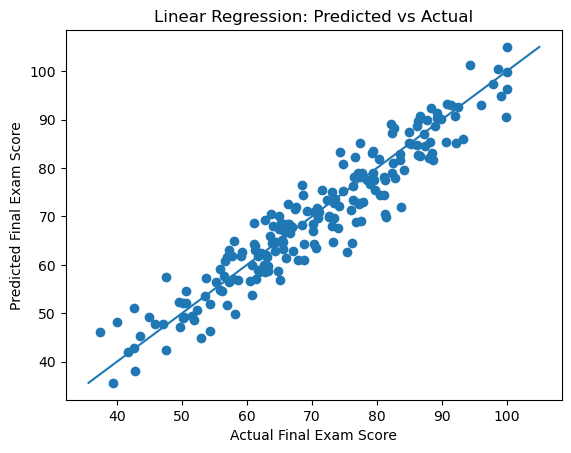

In [19]:
import matplotlib.pyplot as plt
import numpy as np

#Add the points (X-axis actual final score, Y-axis predicted final score)
plt.figure()
plt.scatter(y_test, y_pred)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

#Show the graph
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()